#### Dog Breed Ownership
#### Morgan Fry
#### 08/04/2025

This program analyzes a dataset of various dog breeds and their characteristics. It is meant to aide in the decision making process for potential dog owners.  The program will answer the following questions:

1. What commitments are required for dog ownership?

   a) What is the average exercise requirements per day?

   b) What does the distribution of grooming needs look like?

   c) What is the average training difficulty?

   b) What is the average lifespan and how does weight correlate?


2. What are the averages of various traits of the types of dog breeds?

3. Which dog breed is ideal based on user input?

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Data citation
Prajwal Dongre (2024). _150+ Dog Breeds Around the World_ [Data set]. https://www.kaggle.com/datasets/prajwaldongre/top-dog-breeds-around-the-world?resource=download&select=Dog+Breads+Around+The+World.csv

### Explore data

In [3]:
#read dataset & show info
dogs = pd.read_csv('/Notebooks/datasets/dog_breeds.csv')
dogs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Name                             159 non-null    object 
 1   Origin                           159 non-null    object 
 2   Type                             159 non-null    object 
 3   Unique Feature                   159 non-null    object 
 4   Friendly Rating (1-10)           159 non-null    int64  
 5   Life Span                        159 non-null    int64  
 6   Size                             159 non-null    object 
 7   Grooming Needs                   159 non-null    object 
 8   Exercise Requirements (hrs/day)  159 non-null    float64
 9   Good with Children               159 non-null    object 
 10  Intelligence Rating (1-10)       159 non-null    int64  
 11  Shedding Level                   159 non-null    object 
 12  Health Issues Risk    

In [4]:
dogs.head()

,Name,Origin,Type,Unique Feature,Friendly Rating (1-10),Life Span,Size,Grooming Needs,Exercise Requirements (hrs/day),Good with Children,Intelligence Rating (1-10),Shedding Level,Health Issues Risk,Average Weight (kg),Training Difficulty (1-10)
0,Affenpinscher,Germany,Toy,Monkey-like face,7,14,Small,High,1.5,Yes,8,Moderate,Low,4,6
1,Afghan Hound,Afghanistan,Hound,Long silky coat,5,13,Large,Very High,2.0,No,4,High,Moderate,25,8
2,Airedale Terrier,England,Terrier,Largest of terriers,8,12,Medium,High,2.0,Yes,7,Moderate,Low,21,6
3,Akita,Japan,Working,Strong loyalty,6,11,Large,Moderate,2.0,With Training,7,High,High,45,9
4,Alaskan Malamute,Alaska USA,Working,Strong pulling ability,7,11,Large,High,3.0,Yes,6,Very High,Moderate,36,8


### Question 1: What commitments are required for dog ownership?


#### a) What is the average exercise requirements per day?

In [193]:
#use describe() for exercise req column to find stats
dogs['Exercise Requirements (hrs/day)'].describe()

count    159.000000
mean       1.842767
std        0.450521
min        1.000000
25%        1.500000
50%        2.000000
75%        2.000000
max        3.000000
Name: Exercise Requirements (hrs/day), dtype: float64

Text(0.5, 0.98, 'Histogram of Excercise Requirements per Day')

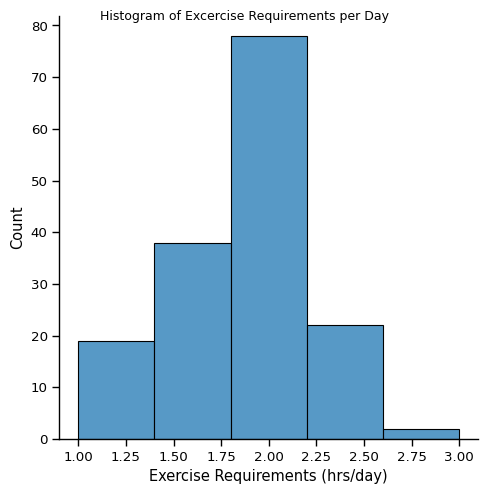

In [194]:
#exercise requirement histogram
hist_ex = sns.displot(dogs['Exercise Requirements (hrs/day)'], bins=5)
hist_ex.fig.suptitle('Histogram of Excercise Requirements per Day', fontsize=9)

#### b) What does the distribution of grooming needs look like?

In [38]:
#explore unique values in column Grooming Needs
dogs['Grooming Needs'].unique()

array(['High', 'Very High', 'Moderate', 'Low'], dtype=object)

In [44]:
#convert grooming needs dtype to categorical to order needs from low to very high for histogram
dogs['Grooming Needs'] = pd.Categorical(dogs['Grooming Needs'], ['Low','Moderate','High','Very High'], ordered=True)
dogs['Grooming Needs'].dtype

CategoricalDtype(categories=['Low', 'Moderate', 'High', 'Very High'], ordered=True, categories_dtype=object)

Text(0.5, 0.98, 'Histogram of Grooming Needs')

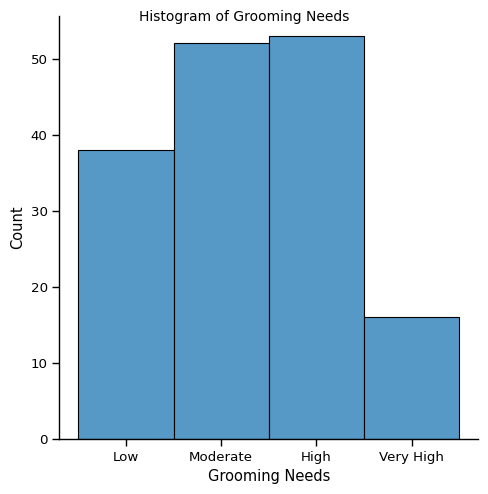

In [45]:
#grooming needs histogram
hist_gr = sns.displot(dogs['Grooming Needs'])
hist_gr.fig.suptitle('Histogram of Grooming Needs', fontsize=10)

#### c) What is the average training difficulty?

In [47]:
#use describe() for training difficulty column to find stats
dogs['Training Difficulty (1-10)'].describe()

count    159.000000
mean       6.572327
std        0.964294
min        4.000000
25%        6.000000
50%        7.000000
75%        7.000000
max        9.000000
Name: Training Difficulty (1-10), dtype: float64

Text(0.5, 0.98, 'Histogram of Training Difficulty')

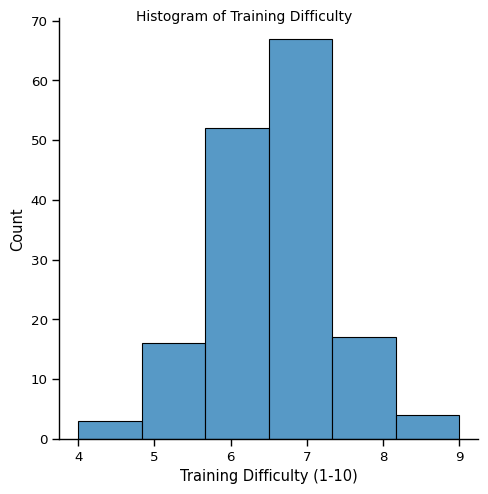

In [49]:
#training difficulty histogram
hist_tr = sns.displot(dogs['Training Difficulty (1-10)'], bins=6)
hist_tr.fig.suptitle('Histogram of Training Difficulty', fontsize=10)

#### d) What is the average lifespan and how does weight correlate?

In [51]:
#use describe() for lifespan to find stats
dogs['Life Span'].describe()

count    159.000000
mean      12.050314
std        1.574314
min        7.000000
25%       11.000000
50%       12.000000
75%       13.000000
max       16.000000
Name: Life Span, dtype: float64

In [53]:
#convert weight column to numeric data type
#& use column calculation to create new column weight_lbs
dogs['weight_lbs'] = (pd.to_numeric(dogs['Average Weight (kg)'], errors='coerce') * 2.20462).round(1)
dogs['weight_lbs']

0       8.8
1      55.1
2      46.3
3      99.2
4      79.4
       ... 
154    17.6
155    17.6
156    44.1
157     NaN
158     5.5
Name: weight_lbs, Length: 159, dtype: float64

Text(0.5, 0.98, 'Scatterplot of Size of Dog Breed and Life Span by Health Issues Risk')

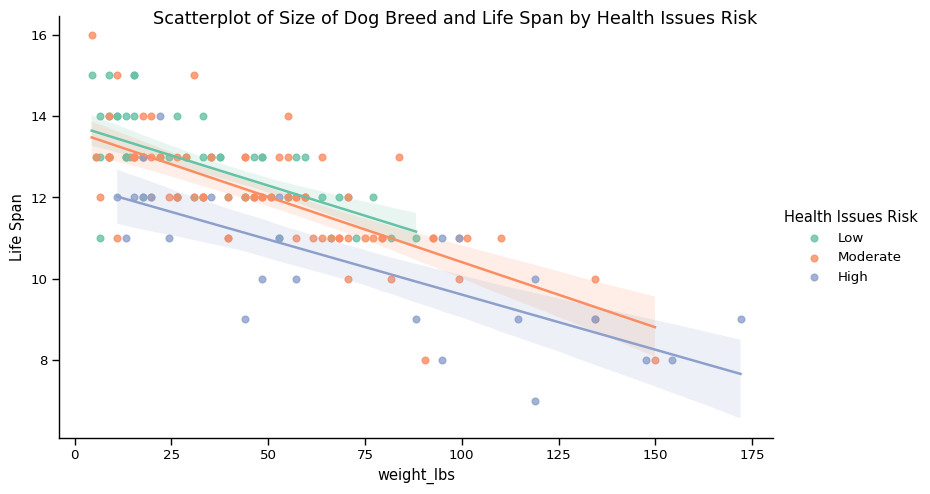

In [56]:
#scatter plot w/ regression line of weight and life span by health risk
#set font size
sns.set_context('paper', font_scale =1.1)
#create scatterplot
scatter1 = sns.lmplot(x='weight_lbs', y='Life Span', hue='Health Issues Risk', data=dogs, palette='Set2', fit_reg=True, height=5, aspect=1.6)
#add title
scatter1.fig.suptitle('Scatterplot of Size of Dog Breed and Life Span by Health Issues Risk')

### What are the averages of various traits of the types of dog breeds?

In [59]:
#explore unique values in Type column
dogs['Type'].value_counts()

Type
Hound           27
Working         26
Sporting        26
Terrier         21
Non-Sporting    20
Toy             19
Herding         18
Standard         2
Name: count, dtype: int64

In [60]:
#set groupby object
type_group = dogs.groupby('Type')
type_group

In [196]:
#see count per type and mean friendliness, life span, excercise, intelligence, training, & weight
type_avgs=type_group[['Life Span','weight_lbs','Exercise Requirements (hrs/day)',
                      'Training Difficulty (1-10)','Friendly Rating (1-10)',
                      'Intelligence Rating (1-10)']].agg('mean')
type_avgs

,Life Span,weight_lbs,Exercise Requirements (hrs/day),Training Difficulty (1-10),Friendly Rating (1-10),Intelligence Rating (1-10)
Type,,,,,,
Herding,12.277778,46.188889,2.166667,6.277778,7.833333,8.000000
Hound,11.703704,53.559259,2.037037,7.000000,6.925926,6.555556
Non-Sporting,12.450000,29.694737,1.650000,6.400000,7.600000,7.400000
Sporting,11.961538,52.307692,2.096154,5.846154,7.884615,7.269231
Standard,13.500000,24.250000,1.750000,6.000000,7.500000,7.500000
Terrier,13.142857,21.661905,1.666667,6.714286,7.285714,6.952381
Toy,13.105263,8.452632,1.157895,6.210526,7.684211,7.157895
Working,10.269231,101.923077,1.961538,7.384615,7.346154,6.769231


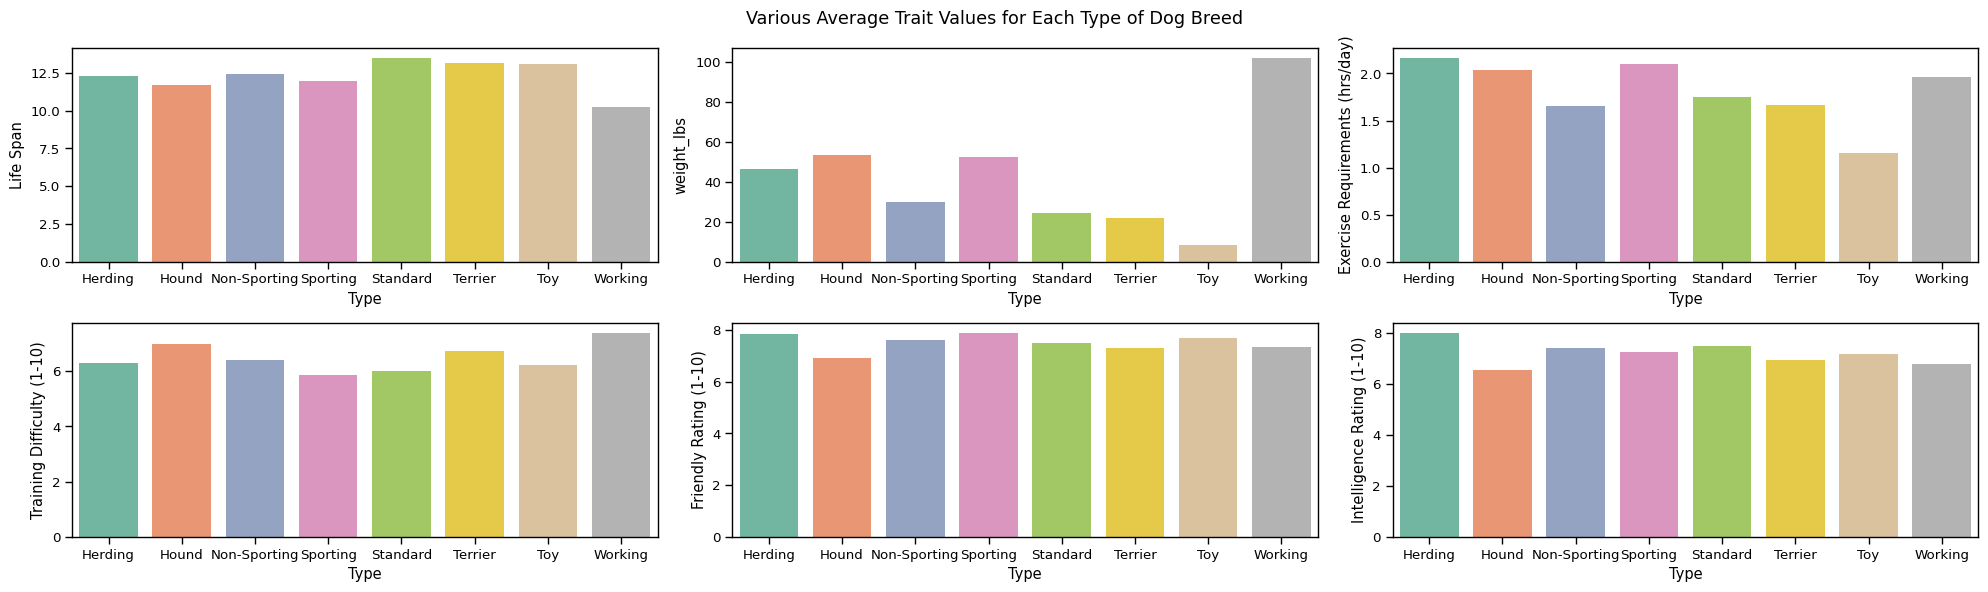

In [131]:
#create figure with subplots for type avg data
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 6))
fig.suptitle('Various Average Trait Values for Each Type of Dog Breed')

#bar plot for life span
sns.barplot(x='Type',y='Life Span', data=type_avgs, hue='Type', palette='Set2', ax=ax[0,0])
#bar plot for weight
sns.barplot(x='Type',y='weight_lbs', data=type_avgs, hue='Type', palette='Set2', ax=ax[0,1])
#bar plot for excercise
sns.barplot(x='Type',y='Exercise Requirements (hrs/day)', data=type_avgs, hue='Type', palette='Set2', ax=ax[0,2])
#bar plot for training
sns.barplot(x='Type',y='Training Difficulty (1-10)', data=type_avgs, hue='Type', palette='Set2', ax=ax[1,0])
#bar plot for friendly
sns.barplot(x='Type',y='Friendly Rating (1-10)', data=type_avgs, hue='Type', palette='Set2', ax=ax[1,1])
#bar plot for intelligence
sns.barplot(x='Type',y='Intelligence Rating (1-10)', data=type_avgs, hue='Type', palette='Set2', ax=ax[1,2])

plt.tight_layout()
plt.show()

### 3. Which dog breed is ideal based on user input?

In [132]:
#create lower case columns for filtering
dogs['Size_l'] = dogs['Size'].str.lower()
dogs['Grooming Needs_l'] = dogs['Grooming Needs'].str.lower()
dogs['Good with Children_l'] = dogs['Good with Children'].str.lower()
dogs['Shedding Level_l'] = dogs['Shedding Level'].str.lower()
#dogs

In [187]:
#create filtering variables from user inputs
size = input('What size dog breed would you like? (Input toy, small, medium, large, or giant:').lower()
friend = int(input('On a scale of 1-10, how friendly of a dog breed would you like?:'))
excercise = float(input('How many hours per day are you willing to excercise your dog? (input value from 1-3):'))
children = input('Does your dog breed need to be good with children? (Input yes or no):').lower()
intelligence = int(input('On a scale of 1-10, how intelligent would you like your dog breed to be?'))
shed = input('How much shedding are you okay with? (Input low, moderate, high, or very high').lower()
train = int(input('On a scale of 1-10, how much effort are you willing to put into training?:'))

#create if statement for children input so that lower tiers are returned from user input
if children == 'yes':
    children = ['yes','with training']
elif children == 'no':
    children = ['yes','no','with training']
    
#create if statement for shed input so that lower tiers are returned from user input   
if shed == 'very high':
    shed = ['low', 'moderate','high','very high']
elif shed == 'high':
    shed = ['low', 'moderate','high']
elif shed == 'moderate':
    shed = ['low', 'moderate']
elif shed == 'low':
    shed = ['low']

What size dog breed would you like? (Input toy, small, medium, large, or giant: medium
On a scale of 1-10, how friendly of a dog breed would you like?: 5
How many hours per day are you willing to excercise your dog? (input value from 1-3): 2
Does your dog breed need to be good with children? (Input yes or no): no
On a scale of 1-10, how intelligent would you like your dog breed to be? 6
How much shedding are you okay with? (Input low, moderate, high, or very high high
On a scale of 1-10, how much effort are you willing to put into training?: 9


In [192]:
#filter dataset with user input
breed_for_user = dogs[
    (dogs['Size_l'] == size) & 
    ((dogs['Friendly Rating (1-10)'] >= friend-1) & (dogs['Friendly Rating (1-10)'] <= friend+1)) & 
    (dogs['Exercise Requirements (hrs/day)'] <= excercise) &
    (dogs['Good with Children_l'].isin(children)) &
    ((dogs['Intelligence Rating (1-10)'] >= intelligence-1) & (dogs['Intelligence Rating (1-10)'] <= intelligence+1)) &
    (dogs['Shedding Level_l'].isin(shed)) &
    (dogs['Training Difficulty (1-10)'] <= train)
    ]

#create if statement to output error message if dataset is empty
if len(breed_for_user) > 0:
    print('The following table contains data on dog breeds that may be right for you:')
    display(breed_for_user.iloc[:,:16])
else:
    print('No dog breeds match your search criteria.')

The following table contains data on dog breeds that may be right for you:


,Name,Origin,Type,Unique Feature,Friendly Rating (1-10),Life Span,Size,Grooming Needs,Exercise Requirements (hrs/day),Good with Children,Intelligence Rating (1-10),Shedding Level,Health Issues Risk,Average Weight (kg),Training Difficulty (1-10),weight_lbs
38,Chinese Shar-Pei,China,Non-Sporting,Wrinkled skin,6,10,Medium,Low,1.5,With Training,6,Moderate,High,22,8,48.5
39,Chow Chow,China,Non-Sporting,Blue-black tongue,5,10,Medium,High,1.5,No,5,High,High,26,9,57.3
146,Thai Ridgeback,Thailand,Hound,Ridge of fur on back,6,12,Medium,Moderate,2.0,With Training,7,Moderate,Moderate,15,7,33.1
